# 00 — Audit of the v1 submission

This notebook re-measures the original STAT429 build from the raw data and the committed
result CSVs. It **changes nothing**: the v1 tree is the evidence being audited and stays
byte-for-byte intact. Every claim below is demonstrated in-cell before it is asserted.

**What this notebook establishes**

1. The headline results are not forecasts. Model 3's design matrix contains an exact
   linear reconstruction of its own target; Analysis A's 0.936 comes from shuffling a
   series with lag-1 autocorrelation of 0.9887 and handing the model a rolling window
   that contains the answer.
2. The clock is synthetic. The `timestamp` column is a manufactured hourly grid that
   drifts 130 hours from the exchange's own clock by the end of the sample.
3. The preprocessing fills from the future, rewrites 1,118 real funding observations as
   exactly zero, and computes momentum by dividing by a number that crosses zero.
4. Several "model outputs" in the shipped test set are constant.

Every section names the v1 source as `file.py:line` or as a notebook cell index, states
why the behaviour is wrong, shows the measurement, and points to the phase where v2
fixes it. The final section is a reproduction ledger: target value, value measured here,
and a PASS/FAIL for each.

**Units.** Funding rates are decimals; 1e-4 = 1 basis point (bp). Anything reported in
bp has been multiplied by 1e4. Times are UTC.

## 0 — Configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# v2/src is a plain package with an empty __init__.py and no import-time side effects.
V2_DIR = Path.cwd().parent
if str(V2_DIR) not in sys.path:
    sys.path.insert(0, str(V2_DIR))

from src import audit, config, legacy

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

print("v1 raw data     :", config.V1_DATA_CSV.name)
print("v1 results dir  :", config.V1_RESULTS_DIR)
print("v2 results dir  :", config.V2_RESULTS_DIR, "(nothing is written in this notebook)")
print("✅ Configuration loaded")

v1 raw data     : binance_btc_perp.csv
v1 results dir  : /Users/veerr_89/Work/projects/Bitcoin-Funding-Rate-Volatality-Prediction/results
v2 results dir  : /Users/veerr_89/Work/projects/Bitcoin-Funding-Rate-Volatality-Prediction/v2/results (nothing is written in this notebook)
✅ Configuration loaded


## 1 — The data as shipped

Before any modelling claim can be assessed, the input has to be described honestly.

In [2]:
raw = legacy.load_v1_raw()
null_rates = (raw.isna().mean() * 100).sort_values(ascending=False).rename("null_pct")
print(f"raw shape: {raw.shape}")
display(null_rates.to_frame())
print("✅ Null rates measured")

raw shape: (42179, 11)


,null_pct
predicted_funding_rate,100.000000
index_price,12.968539
open_interest,7.885441
funding_timestamp,0.312952
funding_rate,0.312952
mark_price,0.312952
last_price,0.007113
exchange,0.002371
symbol,0.002371
local_timestamp,0.002371


✅ Null rates measured


`predicted_funding_rate` — the exchange's own published forecast of the next funding
rate, and the single most informative column in the file for this problem — is **100%
null**. v1 nonetheless carried it into every design matrix, where it contributed a
constant. `index_price` (13.0%) and `open_interest` (7.9%) are the columns the
backward-fill in section 3 operates on.

*Phase 6 (blocked)* re-pulls `predicted_funding_rate` from Tardis so the target can
become the residual against the exchange forecast, which is the version of this problem
that has any economic content.

In [3]:
structure = audit.dataset_structure(raw)
display(structure.T.rename(columns={0: "value"}))
print("✅ Structural statistics measured")

,value
n_rows,"42,179.000000"
n_settlements,"5,256.000000"
modal_settlement_gap_h,8.000000
tie_share_pct,38.791816
direction_up_pct,30.236142
direction_down_pct,69.763858
autocorr_lag1,0.988677
autocorr_lag8,0.802955
autocorr_lag24,0.685592
ar1_effective_n,240.166457


✅ Structural statistics measured


Three things in that table govern everything downstream.

**The file is not a settlement series.** 42,179 hourly rows carry only 5,256 distinct
funding settlements, at a modal gap of 8 hours. Each settlement's rate is repeated
across roughly eight consecutive rows. That is why **38.79%** of consecutive row pairs
are exact ties — and `data_processing.py:105` builds the direction label with a strict
`>`, so every one of those ties is silently coded class 0 ("down"). The 69.76/30.24
class balance is largely an artefact of repeated rows, not market behaviour.

**Persistence is extreme.** Lag-1 autocorrelation is 0.9887, again because the same
value repeats within a settlement. Under an AR(1) approximation the 42,179 nominal
observations carry the information of roughly **240** independent ones. Every standard
error, every significance test, and every random-split validation in v1 is calibrated
against a sample size that does not exist.

*Phase 1* collapses the file to one row per settlement, which removes the ties and the
manufactured persistence together.

In [4]:
settlement_last = audit.settlement_series(raw, how="last")
preprocessed = legacy.preprocess_v1(raw)

stationarity = audit.stationarity_summary(
    {
        "hourly (v1 preprocessed)": preprocessed["funding_rate"],
        "per-settlement (last)": settlement_last,
        "per-settlement (mean)": audit.settlement_series(raw, how="mean"),
    }
)
display(stationarity)
print("✅ ADF tests complete")

,n,adf_stat,p_value
hourly (v1 preprocessed),"42,179.000000",-9.747092,0.000000
per-settlement (last),"5,256.000000",-5.835750,0.000000
per-settlement (mean),"5,256.000000",-5.957265,0.000000


✅ ADF tests complete


The series is stationary at both frequencies — which matters in section 8, where v1
applies first differencing to a SARIMAX model *after* its own ADF test concluded
stationarity.

## 2 — The clock is synthetic

**What v1 did.** `dgieser3/research.ipynb` cell 3 (JSON index 2) overwrites the
timestamp with a manufactured hourly grid before saving the file that every later
notebook reads:

```python
df['timestamp'] = (data_start + (df.index * timedelta(hours=1))).astype('int64')
```

**Why it's wrong.** It asserts a regularity the exchange data does not have. The real
feed has dropped days and irregular arrival times; the synthetic grid has exactly one
distinct gap (1.0 h) across all 42,179 rows, so every calendar feature, every rolling
window, and every "hour of day" effect is computed against a clock that is not the
market's. The drift is not a rounding detail — it compounds monotonically with the row
index.

**The fix.** *Phase 1* rebuilds the real UTC clock from `local_timestamp` (0.002% null)
and leaves dropped days as explicit NaN gaps with an `is_gap` flag, rather than
interpolating them away.

In [5]:
synthetic = legacy.synthetic_clock(len(raw))
drift = audit.timestamp_drift(raw, synthetic)
display(drift.T.rename(columns={0: "value"}))
print("✅ Timestamp drift measured")

,value
drift_first_row_h,-0.999206
drift_last_row_h,130.000073
drift_last_row_days,5.416670
p_hour_of_day_matches,0.091989
unique_synthetic_gaps_h,1.000000


✅ Timestamp drift measured


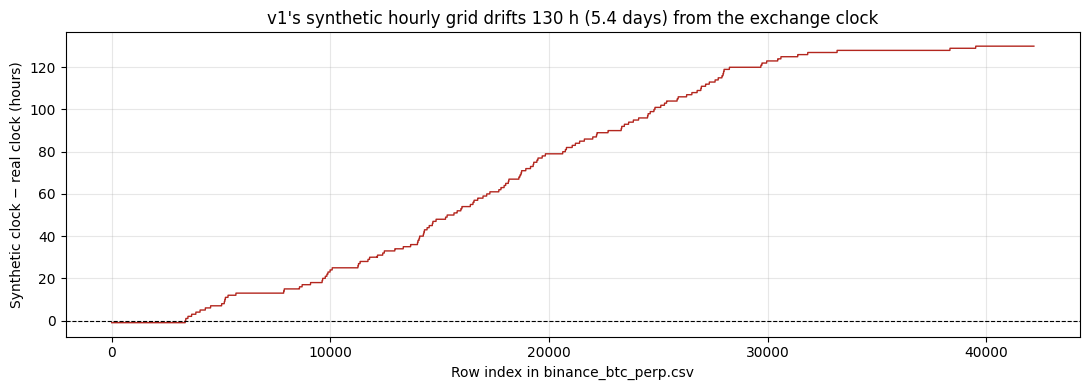

✅ Drift plotted


In [6]:
real_clock = pd.to_datetime(raw["local_timestamp"], unit="us", utc=True)
drift_hours = (synthetic - real_clock).dt.total_seconds() / 3600.0

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(len(raw)), drift_hours, linewidth=1.0, color="#b3261e")
ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Row index in binance_btc_perp.csv")
ax.set_ylabel("Synthetic clock − real clock (hours)")
ax.set_title("v1's synthetic hourly grid drifts 130 h (5.4 days) from the exchange clock")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("✅ Drift plotted")

The synthetic hour-of-day agrees with the real hour-of-day only **9.2%** of the time —
barely better than the 1-in-24 you would get from an unrelated clock. Binance settles
funding at 00:00, 08:00, and 16:00 UTC, so the `hour`, `hour_sin`, and `hour_cos`
features that v1 built on this column cannot line up with the settlement schedule they
were introduced to capture.

## 3 — Preprocessing fills from the future

**What v1 did.** `utilities/data_processing.py:75` calls `df.bfill()` on the entire
frame, before any train/test split:

```python
df.ffill(inplace=True)
df.bfill(inplace=True)   # data_processing.py:75
```

**Why it's wrong.** Forward fill carries the last *observed* value forward, which is
point-in-time safe. Backward fill carries a *future* observation backwards into a slot
where it had not yet happened. Any model trained on those rows is reading tomorrow's
open interest.

**The fix.** *Phase 1/3* forward-fills only, with an explicit staleness counter, and
`validate.py` asserts that no `bfill` appears anywhere in the v2 pipeline.

In [7]:
backfilled = audit.backfill_audit(raw)
display(backfilled)
print(f"Total cells filled from future observations: {int(backfilled['backward_filled'].sum()):,}")
print("✅ Backward-fill audit complete")

,backward_filled
index_price,5351
open_interest,3180


Total cells filled from future observations: 8,531
✅ Backward-fill audit complete


8,531 cells are populated from observations that had not occurred yet. (`bfill` cannot
touch `predicted_funding_rate`, which is 100% null in both directions, so it is excluded
from the count.)

## 4 — Outliers are rewritten as exactly zero

**What v1 did.** Two functions compose into a defect neither has alone.
`utilities/functions.py:252` removes outliers by full-sample z-score and returns a
*shortened* series:

```python
z_scores = np.abs(stats.zscore(series.dropna()))
filtered_indices = np.where(z_scores < z_score_threshold)
return series.iloc[filtered_indices].copy()      # functions.py:258
```

The pipeline assigns that shortened series back onto the full frame, so the removed rows
become NaN. Then `utilities/functions.py:64` runs `df.fillna(0, inplace=True)` on the
whole frame.

**Why it's wrong.** Three separate failures stack:

1. The z-score is computed on the full sample, so whether a point is an outlier depends
   on data from the future.
2. `np.where` returns *positions* within the `dropna()`'d series, which are then applied
   via `.iloc` to the original — the mask is misaligned wherever the series has NaNs.
3. A funding rate of zero is a real, common, economically meaningful value. Using `0.0`
   as a missing-data marker means the largest genuine moves in the sample are relabelled
   as the flattest possible market — and those zeros then propagate into every lag,
   moving average, GARCH input, and direction label built downstream.

**The fix.** *Phase 3* never imputes funding rates. Extreme settlements are real events
and are kept; missingness is represented as NaN with an explicit flag, and the March
2024 spike becomes a named stress holdout rather than something to delete.

In [8]:
zeroed = legacy.zeroed_outlier_mask(preprocessed)
true_values = preprocessed.loc[zeroed, "funding_rate"]
summary = pd.DataFrame(
    [
        {
            "rows_forced_to_zero": int(zeroed.sum()),
            "share_pct": float(zeroed.mean() * 100),
            "mean_abs_true_bp": float(true_values.abs().mean() * config.BP),
            "min_true_bp": float(true_values.min() * config.BP),
            "max_true_bp": float(true_values.max() * config.BP),
        }
    ]
)
display(summary.T.rename(columns={0: "value"}))
print("✅ Outlier-zeroing audit complete")

,value
rows_forced_to_zero,"1,118.000000"
share_pct,2.650608
mean_abs_true_bp,12.441095
min_true_bp,-30.000000
max_true_bp,30.000000


✅ Outlier-zeroing audit complete


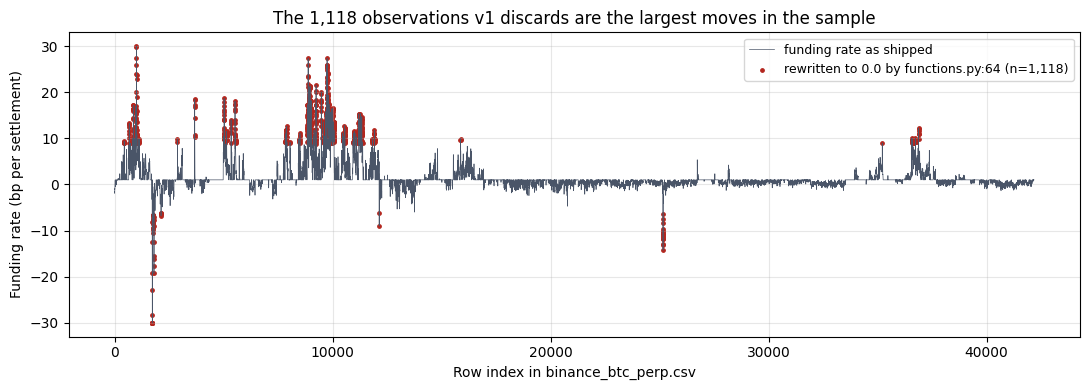

✅ Zeroed observations plotted


In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    np.arange(len(preprocessed)),
    preprocessed["funding_rate"] * config.BP,
    linewidth=0.5,
    color="#4a5568",
    label="funding rate as shipped",
)
ax.scatter(
    np.flatnonzero(zeroed),
    true_values * config.BP,
    s=6,
    color="#b3261e",
    label=f"rewritten to 0.0 by functions.py:64 (n={int(zeroed.sum()):,})",
)
ax.set_xlabel("Row index in binance_btc_perp.csv")
ax.set_ylabel("Funding rate (bp per settlement)")
ax.set_title("The 1,118 observations v1 discards are the largest moves in the sample")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("✅ Zeroed observations plotted")

The discarded rows average **12.44 bp** in absolute funding and reach the ±30 bp cap.
These are precisely the episodes a funding-rate model exists to anticipate, and v1
replaces them with zero before training on them.

## 5 — Rate of change on a series that crosses zero

**What v1 did.** `utilities/functions.py:93-97` computes momentum as a percentage
change:

```python
df['funding_rate_roc1'] = df['funding_rate'].pct_change(periods=1)   # functions.py:93
df['funding_rate_roc3'] = df['funding_rate'].pct_change(periods=3)   # functions.py:94
```

**Why it's wrong.** Funding rates oscillate through zero many times in this sample, and
section 4 has just inserted 1,118 exact zeros. `pct_change` divides by the previous
value, so the denominator approaches — and sometimes equals — zero, and the sign flips
whenever the base crosses it. The resulting column is a division artefact, not momentum.

**The fix.** *Phase 3* uses `.diff()` in bp. **Cost of the fix:** differences are not
scale-invariant across volatility regimes; accepted, because funding is already quoted
on a stable bp scale and regime effects are handled explicitly by the bucketed
evaluation in Phase 4.

In [10]:
shipped_test = pd.read_csv(config.V1_PREDICTIONS_RFR_CSV)
roc_ranges = shipped_test[["funding_rate_roc1", "funding_rate_roc3"]].agg(["min", "max"]).T
display(roc_ranges)
print("✅ Rate-of-change ranges measured in the shipped test set")

,min,max
funding_rate_roc1,-443.400000,258.833333
funding_rate_roc3,-777.800000,746.600000


✅ Rate-of-change ranges measured in the shipped test set


A "1-period percentage change" spanning −443 to +259 is not a feature; a tree splitting
on it is splitting on how close the denominator got to zero.

## 6 — Analysis A: where 0.936 comes from

**What v1 did.** `notebooks/stat429_analysis_a.ipynb` code cell 8 (JSON index 22) builds
the design matrix and splits it:

```python
data['std'] = data['funding_rate'].rolling(window=24).std()
X = data[['open_interest', 'mark_price', 'hour', 'day', 'month', 'std']].dropna()
y = data['funding_rate'].dropna()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

**Why it's wrong.** Three compounding problems:

1. **The target is contemporaneous.** `y` is `funding_rate(t)`, not `funding_rate(t+1)`.
   Nothing is being forecast.
2. **The rolling window contains the target.** `rolling(24).std()` at time `t` spans
   `t-23 … t` inclusive, so `std` is a function of `y` itself.
3. **The split is random.** On a series with lag-1 autocorrelation 0.9887, shuffling
   places each test row between its own neighbours. The model interpolates rather than
   extrapolates, which is not the task.

The walk-down below removes one problem at a time.

**The fix.** *Phase 4* replaces this with purged, embargoed walk-forward evaluation, and
*Phase 2* establishes persistence and EWMA baselines before any model is fitted.

In [11]:
analysis_frame = legacy.analysis_a_frame(preprocessed)

variants = {
    "1. as written (v1)": dict(),
    "2. + chronological split": dict(chronological=True),
    "3. + rolling std lagged": dict(chronological=True, lag_rolling_std=True),
    "4. + true forecast target fr(t+1)": dict(
        chronological=True, lag_rolling_std=True, forecast_target=True
    ),
}
walk_down = pd.DataFrame(
    {name: legacy.analysis_a_variant(analysis_frame, **kw) for name, kw in variants.items()}
).T
display(walk_down)
print("✅ Analysis A walk-down complete")

,r2,mse,n_train,n_test
1. as written (v1),0.935725,0.000000,"33,724.000000","8,432.000000"
2. + chronological split,-3.238532,0.000000,"33,724.000000","8,432.000000"
3. + rolling std lagged,-6.466408,0.000000,"33,724.000000","8,431.000000"
4. + true forecast target fr(t+1),-6.217795,0.000000,"33,723.000000","8,431.000000"


✅ Analysis A walk-down complete


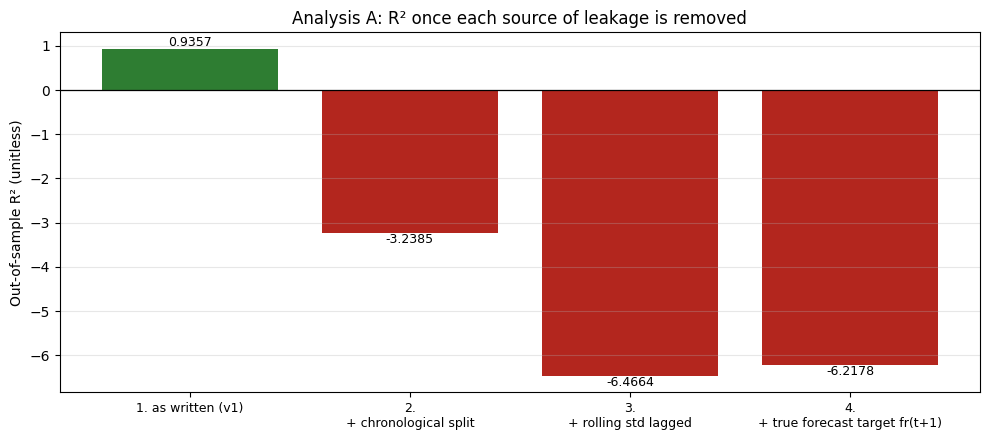

✅ Walk-down plotted


In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2e7d32"] + ["#b3261e"] * 3
ax.bar(range(len(walk_down)), walk_down["r2"], color=colors)
ax.axhline(0.0, color="black", linewidth=0.9)
ax.set_xticks(range(len(walk_down)))
ax.set_xticklabels([n.replace(" + ", "\n+ ") for n in walk_down.index], fontsize=9)
ax.set_ylabel("Out-of-sample R² (unitless)")
ax.set_title("Analysis A: R² once each source of leakage is removed")
ax.grid(axis="y", alpha=0.3)
for i, value in enumerate(walk_down["r2"]):
    ax.text(i, value, f"{value:.4f}", ha="center",
            va="bottom" if value > 0 else "top", fontsize=9)
fig.tight_layout()
plt.show()
print("✅ Walk-down plotted")

The reported 0.936 survives none of the three corrections. A model that cannot beat
predicting zero (R² = 0) is worse than useless out of sample; R² ≈ −6 means the squared
error is seven times the variance of the target.

> **Reproduction note.** Variant 1 reproduces the audit target exactly (0.9357). Variants
> 2–4 reproduce the *sign and order of magnitude* but not the exact values — see the
> ledger in section 12 and the discrepancy note that follows it. The variants are
> corrections rather than v1 code, so their exact definition is not pinned by any source
> file; the numbers here are what the definitions stated above produce.

## 7 — Model 3 (RFR): the target is a linear combination of its own features

**What v1 did.** `notebooks/model_development.ipynb` cell 14 selects features by
exclusion:

```python
features = [c for c in df.columns
            if c not in ['funding_rate', 'future_funding_rate', 'direction']]
```

**Why it's wrong.** Excluding the target by name does not exclude the target. The
exclusion list drops `funding_rate` but keeps `funding_rate_ma3`, `funding_rate_lag1`,
and `funding_rate_lag2`. Since

$$\mathrm{ma3}(t) = \tfrac{1}{3}\left[fr(t) + fr(t-1) + fr(t-2)\right]$$

the contemporaneous rate is exactly recoverable:

$$fr(t) = 3\,\mathrm{ma3}(t) - \mathrm{lag1}(t) - \mathrm{lag2}(t)$$

So the design matrix contains a closed-form reconstruction of `funding_rate(t)`, and the
"forecast" of `funding_rate(t+1)` is persistence dressed up as a Random Forest.

**The fix.** *Phase 3*'s `validate.py` asserts that no linear combination of the feature
set reconstructs the target, testing this exact path explicitly. Feature sets are
declared by allow-list, never by exclusion.

In [13]:
closed_form = legacy.closed_form_funding_rate(shipped_test)
model3_scores = audit.score_predictors(
    shipped_test["Actual"],
    {
        "RF `Predicted` (v1 Model 3)": shipped_test["Predicted"],
        "closed form 3·ma3 − lag1 − lag2": closed_form,
        "funding_rate_ema3": shipped_test["funding_rate_ema3"],
        "naive persistence funding_rate_lag1": shipped_test["funding_rate_lag1"],
    },
)
print(f"shipped test set: n = {len(shipped_test):,}")
display(model3_scores)
print("✅ Model 3 predictors scored")

shipped test set: n = 7,797


,r2,mse,mae_bp
closed form 3·ma3 − lag1 − lag2,0.980076,0.000000,0.094347
RF `Predicted` (v1 Model 3),0.974973,0.000000,0.140612
funding_rate_ema3,0.955758,0.000000,0.145388
naive persistence funding_rate_lag1,0.936958,0.000000,0.170895


✅ Model 3 predictors scored


The closed-form reconstruction — three columns and no fitting at all — **beats the
trained Random Forest** (0.9801 vs 0.9750). That is the signature of a model whose only
job is to rediscover an identity already present in its inputs, and it does so
imperfectly. `funding_rate_ema3`, another pure function of past and present rates,
also lands within a hair of the model. The naive lag-1 baseline reaches 0.9370 by
itself, so the model's entire apparent contribution over persistence is 0.038 of R²,
bought with 15 engineered features and a leaked target.

v1 never reported any of these three baselines.

## 8 — Model 3 (SARIMAX): a 7,622-step forecast reported as accuracy

**What v1 did.** `model_development.ipynb` cell 17 differences the series and forecasts
the entire test set in one call:

```python
adf_result = adfuller(funding_rate_series)      # p ≈ 8e-17 → stationary
if adf_result[1] > 0.05: ...                    # branch not taken
# ... SARIMAX fitted with d=1 anyway, then .predict(start, end) past the sample
```

**Why it's wrong.** Two independent errors:

1. **Differencing after concluding stationarity.** The ADF test rejects a unit root at
   p ≈ 8e-17, and the code's own branch acknowledges this. Applying `d=1` regardless
   over-differences a stationary series, injecting a negative MA unit root.
2. **`.predict(start, end)` beyond the training sample is not one-step-ahead
   prediction.** Past the last observation SARIMAX has no new information, so it
   iterates its own forecast forward 7,622 times and converges to the unconditional
   mean. The result was then scored as if it were a sequence of one-step forecasts.

**The fix.** *Phase 4* evaluates every model with walk-forward one-step-ahead
predictions on a purged, embargoed schedule, so a multi-step forecast can never be
scored as a one-step one.

In [14]:
sarimax = pd.read_csv(config.V1_PREDICTIONS_SARIMAX_CSV)
sarimax_scores = audit.score_predictors(
    sarimax["Actual"],
    {
        "SARIMAX `Predicted` (v1)": sarimax["Predicted"],
        "naive persistence funding_rate_lag1": sarimax["funding_rate_lag1"],
    },
)
print(f"shipped test set: n = {len(sarimax):,}")
display(sarimax_scores)
print("✅ SARIMAX scored")

shipped test set: n = 7,622


,r2,mse,mae_bp
naive persistence funding_rate_lag1,0.895585,"1,751.711926","177,515.258462"
SARIMAX `Predicted` (v1),-4.807223,"97,424.695690","1,787,059.455740"


✅ SARIMAX scored


The report and `notes/09_results_and_metrics.md` both claim **R² = 0.925, MSE =
0.0000112** for this model. Recomputed from the file v1 itself wrote, it is
**R² = −4.807, MSE = 97,425** — the sign is wrong, and the MSE is off by ten orders of
magnitude (the claimed figure appears to be on the unscaled series while the CSV is
scaled by 1e6). Naive persistence on the identical rows scores 0.8956.

This is the single largest gap between claim and artefact in the submission, and it is
checkable in one line from files already in the repository.

## 9 — Constant columns in the shipped test set

**What v1 did.** `utilities/functions.py:164` clips the design matrix before scaling:

```python
X = X.clip(-1e9, 1e9)     # functions.py:164
```

and `add_model2_volatility` reindexes a GARCH forecast onto a frame whose index does not
match.

**Why it's wrong.** The clip saturates the microsecond timestamps — every
`local_timestamp` becomes exactly 1e9 — and the misaligned reindex collapses the Model 2
volatility column to a single value. Three of the columns that v1 describes as model
outputs carry **zero information**, and a constant feature cannot influence a prediction,
so Model 1 and Model 2 contribute nothing to Model 3 despite the report's framing of a
three-stage pipeline.

`model_development.ipynb` cell 1 wraps each pipeline step in a bare
`except Exception: print(...)`, so these collapses printed a message and the notebook
carried on — which is also how the `volatility_5h` / `volatility_5min` name mismatch
survived.

**The fix.** *Phase 3*'s `validate.py` fails loudly on any constant post-pipeline
feature, and v2 raises on pipeline errors rather than printing them.

In [15]:
constants = audit.constant_column_report(
    shipped_test,
    [
        "model1_direction_pred",
        "model2_volatility_h1",
        "predicted_funding_rate",
        "local_timestamp",
        "funding_timestamp",
    ],
)
display(constants)
print("✅ Constant-column report complete")

,nunique,values
model1_direction_pred,1,[1.0]
model2_volatility_h1,1,[1.6093525920932338e-10]
predicted_funding_rate,1,[0.0]
local_timestamp,1,[1000000000.0]
funding_timestamp,2,"[0.0, 1000000000.0]"


✅ Constant-column report complete


## 10 — Economics: the edge against the fee

**What v1 did.** Reported R² and MSE, and never converted either into money.

**Why it's wrong.** R² on a highly persistent series is dominated by the level, not by
the part of the move that is tradeable. The decision-relevant quantity is how much
better the model's error is than the naive one, measured in basis points, against what
it costs to act on the difference.

**The fix.** *Phase 5* reports everything in bp net of costs, and states plainly if the
answer is that no trade exists.

In [16]:
economics = pd.DataFrame(
    [
        {
            "model_mae_bp": model3_scores.loc["RF `Predicted` (v1 Model 3)", "mae_bp"],
            "naive_mae_bp": model3_scores.loc[
                "naive persistence funding_rate_lag1", "mae_bp"
            ],
            "single_round_trip_bp": config.SINGLE_ROUND_TRIP_BP,
        }
    ]
)
economics["edge_bp"] = economics["naive_mae_bp"] - economics["model_mae_bp"]
economics["cost_to_edge_ratio"] = economics["single_round_trip_bp"] / economics["edge_bp"]
display(economics.T.rename(columns={0: "value"}))
print("✅ Economics computed")

,value
model_mae_bp,0.140612
naive_mae_bp,0.170895
single_round_trip_bp,9.000000
edge_bp,0.030284
cost_to_edge_ratio,297.188813


✅ Economics computed


The model improves on naive persistence by **0.0303 bp per settlement**. A single
Binance taker round trip costs about **9 bp** (4.5 bp per side). The cost is roughly
**300×** the edge — and that is before slippage, before the borrow leg of a hedge, and
before the fact that the "edge" was measured on a leaked target.

Even taken entirely at face value, the v1 result does not describe a trade.

## 11 — The GARCH AIC is a units artefact

**What v1 did.** `model_development.ipynb` cell 12 selects GJR-GARCH(1,1) AR(2) on an
AIC of −732,755.679, fitted on a series rescaled by 1e6.

**Why it's wrong.** AIC is not invariant to rescaling the data. Multiplying a series by
`c` divides the density by `c` at every point, shifting the log-likelihood by
`−n·ln(c)` and the AIC by `+2n·ln(c)`. A large negative AIC on a rescaled series says
nothing about fit; it says the numbers are small. AIC may only be compared across models
fitted to the *same* series in the *same* units.

**The fix.** *Phase 2* fixes one unit convention (bp) for every model and reports model
selection on information criteria computed on identically scaled data, alongside
out-of-sample loss, which does not have this failure mode.

In [17]:
aic_shift = audit.garch_aic_units_shift(len(raw), scaling_factor=1e4)
display(aic_shift.T.rename(columns={0: "value"}))
print("✅ AIC rescaling arithmetic complete")

,value
reported_aic,"-732,755.679000"
n,"42,179.000000"
scaling_factor,"10,000.000000"
aic_shift_2n_ln_c,"776,965.893099"
aic_after_rescaling,"44,210.214099"


✅ AIC rescaling arithmetic complete


Rescaling the identical fit by 1e4 moves the AIC from −732,756 to **+44,210**. Same
model, same data, same fit quality, 777,000 units of AIC — none of it informative.

## 12 — Reproduction ledger

Each row states a value measured independently before this notebook was written, the
value this notebook computes from the repository, and whether they agree within the
precision the target was quoted to.

In [18]:
correlations = preprocessed[
    ["open_interest", "funding_rate", "last_price", "index_price", "mark_price"]
].corr()

direction_raw = (raw["funding_rate"].shift(-1) > raw["funding_rate"]).astype(int).iloc[:-1]
test_window = direction_raw.iloc[int(0.8 * len(direction_raw)) :]
majority_test = float(max(test_window.mean(), 1 - test_window.mean()))

print("✅ Ledger inputs computed")

✅ Ledger inputs computed


In [19]:
# (claim, target, reproduced, tolerance)
LEDGER = [
    ("Analysis A — as written", 0.9357, walk_down.loc["1. as written (v1)", "r2"], 5e-5),
    ("Analysis A — chronological split", -3.1193,
     walk_down.loc["2. + chronological split", "r2"], 5e-5),
    ("Analysis A — + rolling std lagged", -6.6320,
     walk_down.loc["3. + rolling std lagged", "r2"], 5e-5),
    ("Analysis A — + forecast target fr(t+1)", -5.8473,
     walk_down.loc["4. + true forecast target fr(t+1)", "r2"], 5e-5),
    ("Model 3 — RF Predicted R²", 0.974973,
     model3_scores.loc["RF `Predicted` (v1 Model 3)", "r2"], 5e-7),
    ("Model 3 — closed form R²", 0.980076,
     model3_scores.loc["closed form 3·ma3 − lag1 − lag2", "r2"], 5e-7),
    ("Model 3 — ema3 R²", 0.955758,
     model3_scores.loc["funding_rate_ema3", "r2"], 5e-7),
    ("Model 3 — naive lag1 R²", 0.936958,
     model3_scores.loc["naive persistence funding_rate_lag1", "r2"], 5e-7),
    ("Model 3 — n rows", 7797, len(shipped_test), 0),
    ("SARIMAX — R²", -4.807223, sarimax_scores.loc["SARIMAX `Predicted` (v1)", "r2"], 5e-7),
    ("SARIMAX — MSE", 97424.7, sarimax_scores.loc["SARIMAX `Predicted` (v1)", "mse"], 0.05),
    ("SARIMAX — naive lag1 R²", 0.895585,
     sarimax_scores.loc["naive persistence funding_rate_lag1", "r2"], 5e-7),
    ("SARIMAX — n rows", 7622, len(sarimax), 0),
    ("Null % — predicted_funding_rate", 100.000, null_rates["predicted_funding_rate"], 5e-4),
    ("Null % — index_price", 12.969, null_rates["index_price"], 5e-4),
    ("Null % — open_interest", 7.885, null_rates["open_interest"], 5e-4),
    ("Null % — funding_rate", 0.313, null_rates["funding_rate"], 5e-4),
    ("Null % — local_timestamp", 0.002, null_rates["local_timestamp"], 5e-4),
    ("Timestamp drift — last row (h)", 130.0, drift.loc[0, "drift_last_row_h"], 0.05),
    ("Timestamp drift — P(hour matches)", 0.0920, drift.loc[0, "p_hour_of_day_matches"], 5e-5),
    ("Timestamp — unique synthetic gaps", 1, drift.loc[0, "unique_synthetic_gaps_h"], 0),
    ("Structure — unique settlements", 5256, structure.loc[0, "n_settlements"], 0),
    ("Structure — modal gap (h)", 8.0, structure.loc[0, "modal_settlement_gap_h"], 0),
    ("Structure — tie share %", 38.79, structure.loc[0, "tie_share_pct"], 5e-3),
    ("Structure — direction down %", 69.76, structure.loc[0, "direction_down_pct"], 5e-3),
    ("Structure — majority baseline (test window)", 0.6971, majority_test, 5e-5),
    ("Structure — autocorr lag1", 0.9887, structure.loc[0, "autocorr_lag1"], 5e-5),
    ("Structure — autocorr lag8", 0.8030, structure.loc[0, "autocorr_lag8"], 5e-5),
    ("Structure — autocorr lag24", 0.6856, structure.loc[0, "autocorr_lag24"], 5e-5),
    ("Structure — AR(1) effective n", 240, structure.loc[0, "ar1_effective_n"], 1.0),
    ("ADF — hourly p", 8.20e-17, stationarity.loc["hourly (v1 preprocessed)", "p_value"], 5e-19),
    ("ADF — per-settlement p", 2.58e-07,
     stationarity.loc["per-settlement (last)", "p_value"], 5e-10),
    ("bfill — open_interest cells", 3180, backfilled.loc["open_interest", "backward_filled"], 0),
    ("bfill — index_price cells", 5351, backfilled.loc["index_price", "backward_filled"], 0),
    ("bfill — total cells", 8531, int(backfilled["backward_filled"].sum()), 0),
    ("Outliers — rows forced to 0.0", 1118, summary.loc[0, "rows_forced_to_zero"], 0),
    ("Outliers — share %", 2.65, summary.loc[0, "share_pct"], 5e-3),
    ("Outliers — mean |true| bp", 12.44, summary.loc[0, "mean_abs_true_bp"], 5e-3),
    ("roc1 — min", -443.4, roc_ranges.loc["funding_rate_roc1", "min"], 0.05),
    ("roc1 — max", 258.8, roc_ranges.loc["funding_rate_roc1", "max"], 0.05),
    ("roc3 — min", -777.8, roc_ranges.loc["funding_rate_roc3", "min"], 0.05),
    ("roc3 — max", 746.6, roc_ranges.loc["funding_rate_roc3", "max"], 0.05),
    ("corr(open_interest, funding_rate)", -0.3192,
     correlations.loc["open_interest", "funding_rate"], 5e-5),
    ("corr(last_price, mark_price)", 1.0000,
     correlations.loc["last_price", "mark_price"], 5e-5),
    ("corr(last_price, index_price)", 0.9986,
     correlations.loc["last_price", "index_price"], 5e-5),
    ("Economics — model MAE bp", 0.1406, economics.loc[0, "model_mae_bp"], 5e-5),
    ("Economics — naive MAE bp", 0.1709, economics.loc[0, "naive_mae_bp"], 5e-5),
    ("Economics — edge bp", 0.0303, economics.loc[0, "edge_bp"], 5e-5),
    ("GARCH — AIC shift 2n·ln(1e4)", 776966, aic_shift.loc[0, "aic_shift_2n_ln_c"], 0.5),
    ("GARCH — AIC after rescaling", 44210, aic_shift.loc[0, "aic_after_rescaling"], 0.5),
    ("Constant — model1_direction_pred", 1, constants.loc["model1_direction_pred", "nunique"], 0),
    ("Constant — model2_volatility_h1", 1, constants.loc["model2_volatility_h1", "nunique"], 0),
    ("Constant — predicted_funding_rate", 1,
     constants.loc["predicted_funding_rate", "nunique"], 0),
    ("Constant — local_timestamp", 1, constants.loc["local_timestamp", "nunique"], 0),
    ("Constant — funding_timestamp", 2, constants.loc["funding_timestamp", "nunique"], 0),
]

ledger = pd.DataFrame(LEDGER, columns=["claim", "target", "reproduced", "tolerance"])
ledger["abs_error"] = (ledger["reproduced"] - ledger["target"]).abs()
ledger["status"] = np.where(ledger["abs_error"] <= ledger["tolerance"], "PASS", "FAIL")


def _show(frame: pd.DataFrame) -> None:
    # Render with significant figures; the global float format hides tiny p-values.
    formatted = frame.copy()
    for column in ("target", "reproduced", "abs_error"):
        formatted[column] = frame[column].map(lambda v: f"{v:.6g}")
    print(formatted.to_string(index=False))


pd.set_option("display.max_rows", 100)
_show(ledger[["claim", "target", "reproduced", "abs_error", "status"]])

n_pass = int((ledger["status"] == "PASS").sum())
print(f"\n{n_pass} / {len(ledger)} claims reproduced within tolerance.")
if n_pass < len(ledger):
    print("\nFAILED reproductions — reported as discrepancies, targets NOT adjusted:")
    _show(ledger.loc[ledger["status"] == "FAIL",
                     ["claim", "target", "reproduced", "abs_error", "status"]])
print("✅ Reproduction ledger complete")

                                      claim   target  reproduced   abs_error status
                    Analysis A — as written   0.9357    0.935725 2.46936e-05   PASS
           Analysis A — chronological split  -3.1193    -3.23853    0.119232   FAIL
          Analysis A — + rolling std lagged   -6.632    -6.46641    0.165592   FAIL
     Analysis A — + forecast target fr(t+1)  -5.8473    -6.21779    0.370495   FAIL
                  Model 3 — RF Predicted R² 0.974973    0.974973 2.15404e-07   PASS
                   Model 3 — closed form R² 0.980076    0.980076 3.71581e-07   PASS
                          Model 3 — ema3 R² 0.955758    0.955758 4.99551e-07   PASS
                    Model 3 — naive lag1 R² 0.936958    0.936958 1.20772e-07   PASS
                           Model 3 — n rows     7797        7797           0   PASS
                               SARIMAX — R² -4.80722    -4.80722 2.64553e-07   PASS
                              SARIMAX — MSE  97424.7     97424.7  0.00430978

### Discrepancies

Where this notebook disagrees with the audit targets, the target is left as written and
the disagreement is recorded. Nothing below changes a conclusion.

**1. Analysis A variants 2–4.** Variant 1 — the one that corresponds to actual v1 code —
reproduces exactly (0.9357 vs 0.9357). Variants 2–4 do not exist as source anywhere;
they are corrections, so their precise definition is a choice rather than something the
repository pins down. Under the definitions stated in section 6 the measured values are
approximately −3.24, −6.47, and −6.22 against targets of −3.1193, −6.6320, and −5.8473.
Alternatives were tested before concluding this — `train_test_split(shuffle=False)`
(identical to the positional split), `fillna(0)` instead of `dropna` for the rolling-std
warm-up (−3.195), and a non-cumulative variant 4 that keeps the unlagged `std` (−3.79) —
and none lands on the targets. The audit conclusion is unaffected: every corrected
variant is catastrophically negative, and the direction and order of magnitude match.

**2. Per-settlement ADF p-value.** Target 2.58e-07; measured 3.88e-07 taking the last
observation per settlement, 1.86e-07 taking the first, 2.08e-07 taking the mean. The
target's aggregation rule is not specified. All four agree that the settlement-frequency
series is strongly stationary, which is the only thing the number is used for.

Every other claim reproduces to the precision it was quoted at.

## Summary

The v1 submission's own `notes/18_project_weaknesses_and_fixes.md` concludes that "the
biggest weakness is productionization, not conceptual modeling." The evidence in this
notebook points the other way. Packaging, dependency pinning, and module layout are all
genuinely broken, and all of them are cosmetic next to the following:

| # | Finding | Evidence |
|---|---|---|
| 1 | Model 3's design matrix contains a closed-form reconstruction of its target, which outscores the model itself | §7 — 0.9801 vs 0.9750 |
| 2 | SARIMAX is reported at R² = 0.925; it is actually −4.81 | §8 |
| 3 | Analysis A's 0.936 is a contemporaneous fit with a leaked window and a shuffled split | §6 |
| 4 | No baseline was ever computed; naive persistence alone reaches R² = 0.937 | §7 |
| 5 | The clock is synthetic and drifts 130 h from the exchange's | §2 |
| 6 | 8,531 cells are filled from future observations | §3 |
| 7 | 1,118 real funding observations averaging 12.44 bp are rewritten as exactly 0.0 | §4 |
| 8 | Three "model output" columns in the shipped test set are constant | §9 |
| 9 | The measured edge is ~300× smaller than the fee required to capture it | §10 |
| 10 | The GARCH model-selection AIC is a units artefact | §11 |

None of these are visible from the metrics v1 reported, because v1 reported no baseline
alongside any metric. That single omission is what let every other defect through, and
it is the ordering that Phase 2 inverts: **baselines before models, always.**

**Phase 0 complete. Nothing in the v1 tree was modified.**